In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import xarray as xr

# Load the GRDC text file
df = pd.read_csv('./Data/5202080_Q_Day.Cmd.txt',delimiter=';',skiprows=36,header=0,encoding='cp1252')

# Rename columns
df.columns = ["Date", "Time", "Discharge"]
# Convert discharge to numeric (GRDC uses -999 for missing)
df["Discharge"] = pd.to_numeric(df["Discharge"], errors="coerce")
df.loc[df["Discharge"] < 0, "Discharge"] = pd.NA
# Drop missing discharge values
df = df.dropna(subset=["Discharge"])
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
# Set datetime index
df = df.set_index("Date")
# Drop the useless Time column
df = df.drop(columns=["Time"])
# Sort by date (just in case)
df = df.sort_index()



In [18]:
# Load the potential evaporation data from MODIS
evap_daily_df = pd.read_csv('./Data/manning_MODIS_potevap_8days.csv') # 0.1 mm/8days
evap_daily_df['date'] = pd.to_datetime(evap_daily_df['system:index'], format='%Y_%m_%d')
evap_daily_df.set_index('date', inplace=True)
evap_daily_df.drop(columns=['system:index'], inplace=True)
evap_daily_df['PET'] = evap_daily_df['PET'] * 0.1 # mm/8days
evap_daily_df['PET_daily'] = evap_daily_df['PET'] / 8 # mm/day


In [19]:
evap_daily_df

,PET,PET_daily
date,,
2000-01-01,55.607600,6.950950
2000-01-09,54.027192,6.753399
2000-01-17,61.001282,7.625160
2000-01-25,42.755851,5.344481
2000-02-02,63.091730,7.886466
...,...,...
2025-11-25,64.350756,8.043845
2025-12-03,58.255378,7.281922
2025-12-11,53.887167,6.735896


In [20]:
# Load precip data from ERA5
era5_df = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
era5_df['Date'] = pd.to_datetime(era5_df['system:index'], format='%Y%m%d')
era5_df = era5_df.set_index('Date')[['total_precipitation_sum']].rename(columns={'total_precipitation_sum': 'ERA5_Precipitation'})
evap_daily = evap_daily_df.copy()
precip_daily = era5_df.copy()

In [21]:
# Select data from the same time periods
# Find common dates between evaporation, precipitation, and discharge

common_dates = evap_daily.index.intersection(precip_daily.index).intersection(df.index)

evap_common = evap_daily.loc[common_dates]
precip_common = precip_daily.loc[common_dates]
discharge_common = df.loc[common_dates]


In [31]:
#daily averages
P_mean_mm_day = precip_common["ERA5_Precipitation"].mean()
Ep_mean_m_day = evap_common["PET_daily"].mean()
Q_mean_m3s = discharge_common["Discharge"].mean()

# Catchment area from stationbasins.geojson
area_km2 = 6642  # km²
area_m2 = area_km2 * 1e6  # m²

#yearly averages
P_mean_mm_year = P_mean_mm_day * 1000 * 365
Ep_mean_mm_year = Ep_mean_m_day * 365
Q_mean_mm_year = ((Q_mean_m3s * 86400) / area_m2 * 1000) * 365

print(f"Average Discharge (Q): {Q_mean_mm_year:.2f} mm/year")
print(f"Average Precipitation (P): {P_mean_mm_year:.2f} mm/year")
print(f"Average Evaporation (Ep): {Ep_mean_mm_year:.2f} mm/year")

Average Discharge (Q): 191.46 mm/year
Average Precipitation (P): 1083.22 mm/year
Average Evaporation (Ep): 1611.25 mm/year


In [23]:
AI = Ep_mean_mm_year / P_mean_mm_year
EI = 1 - (Q_mean_mm_year / P_mean_mm_year)

print(P_mean_mm_day)
print(Ep_mean_m_day)
print(Q_mean_m3s)

# Print
print(f"Aridity Index (AI): {AI:.2f}")
print(f"Evaporative Index (EI): {EI:.2f}")

0.0029677268103823332
4.41439109514415
40.32376975945017
Aridity Index (AI): 1.49
Evaporative Index (EI): 0.82


In [32]:
# 3. ANALYTICAL BUDYKO CURVES
phi = np.linspace(0.01, 5, 500)

EaP_schreiber = 1 - np.exp(-phi)
EaP_oldekop = phi * np.tanh(1 / phi)
EaP_budyko = np.sqrt(phi * np.tanh(1/phi) * (1 - np.exp(-phi)))
EaP_turc = 1 / np.sqrt(0.9 + (1/phi)**2)


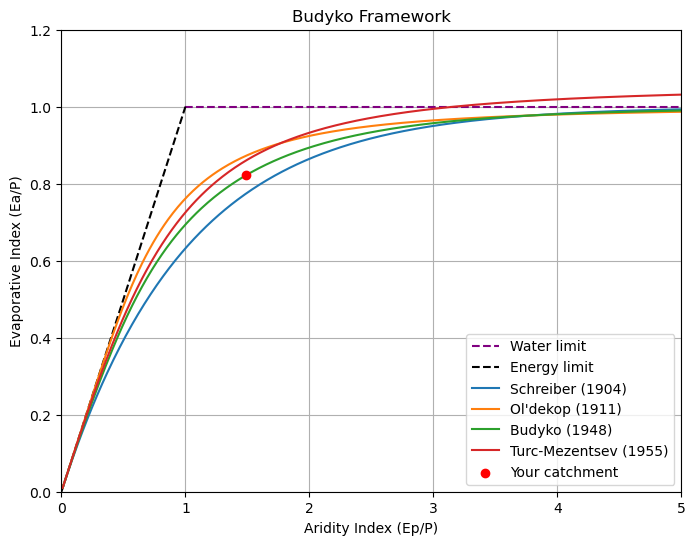

The catchment has an aridity index of a humid climate, which is normal for a coastal region. The evaporative index indicates that a significant portion of precipitation is lost to evaporation, which is also typical for humid climates. The catchment falls below the water limit, suggesting that it is not energy-limited and has sufficient water availability for evaporation.   


In [33]:
plt.figure(figsize=(8,6))
plt.xlim(0, 5)
plt.ylim(0, 1.2)


# Water limit
plt.hlines(1, 1, 5, colors='purple', linestyles='--', label='Water limit')

# Energy limit
phi_energy = np.linspace(0, 1, 200)
plt.plot(phi_energy, phi_energy, 'k--', label='Energy limit')

# Analytical curves
plt.plot(phi, EaP_schreiber, label='Schreiber (1904)')
plt.plot(phi, EaP_oldekop, label='Ol\'dekop (1911)')
plt.plot(phi, EaP_budyko, label='Budyko (1948)')
plt.plot(phi, EaP_turc, label='Turc-Mezentsev (1955)')

# Your catchment point
plt.scatter(AI, EI, color='red', label='Your catchment', zorder=5)

plt.xlabel("Aridity Index (Ep/P)")
plt.ylabel("Evaporative Index (Ea/P)")
plt.title("Budyko Framework")
plt.legend()
plt.grid(True)
plt.show()

print(f'The catchment has an aridity index of a humid climate, which is normal for a coastal region. The evaporative index indicates that a significant portion of precipitation is lost to evaporation, which is also typical for humid climates. The catchment falls below the water limit, suggesting that it is not energy-limited and has sufficient water availability for evaporation.   ')

In [26]:
#PROBLEM 2 - FLOW DURATION CURVES for the catchment area of 6642 km²
#flow duration curve is plotted as exceedence probability by runoff


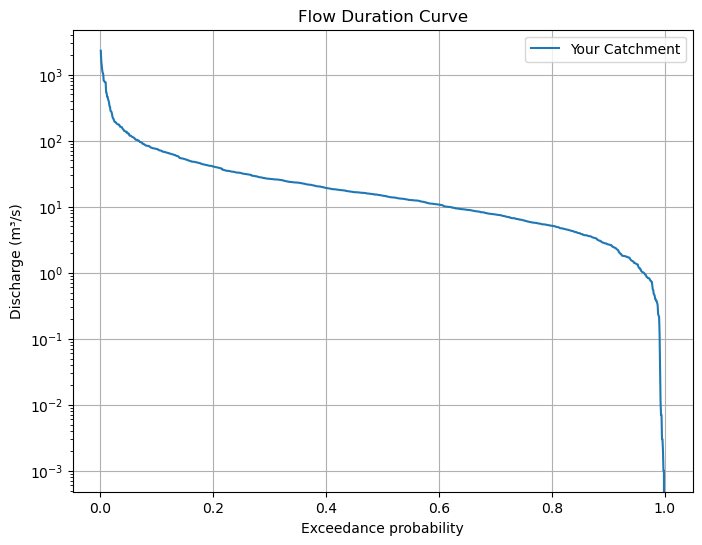

In [34]:
def flow_duration_curve(Q):
    Q_sorted = np.sort(Q)[::-1]  # descending
    N = len(Q_sorted)
    exceedance = np.arange(1, N+1) / (N+1)
    return exceedance, Q_sorted

exceedance, Q_sorted = flow_duration_curve(discharge_common["Discharge"])

plt.figure(figsize=(8,6))
plt.plot(exceedance, Q_sorted, label="Your Catchment")

plt.yscale("log")  # FDCs are almost always plotted on log scale
plt.xlabel("Exceedance probability")
plt.ylabel("Discharge (m³/s)")
plt.title("Flow Duration Curve")
plt.grid(True)
plt.legend()
plt.show()

In [28]:
#PROBLEM 3 the AUTO CORRELATION FUNCTION


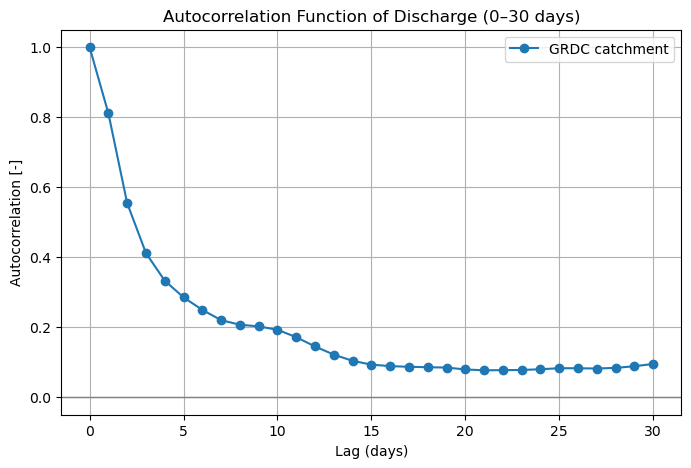

In [37]:

full_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
df = df.reindex(full_index)

def acf(x, max_lag=30):
    x = np.asarray(x, dtype=float)
    acf_vals = np.empty(max_lag + 1)

    for lag in range(max_lag + 1):
        x1 = x[:-lag] if lag > 0 else x
        x2 = x[lag:]  if lag > 0 else x

        mask = np.isfinite(x1) & np.isfinite(x2)
        x1 = x1[mask]
        x2 = x2[mask]

        if len(x1) < 2:
            acf_vals[lag] = np.nan
            continue

        x1 = x1 - np.mean(x1)
        x2 = x2 - np.mean(x2)

        denom = np.sqrt(np.sum(x1**2) * np.sum(x2**2))
        if denom == 0:
            acf_vals[lag] = np.nan
        else:
            acf_vals[lag] = np.sum(x1 * x2) / denom

    return acf_vals


max_lag = 30
lags = np.arange(0, max_lag + 1)
acf_vals = acf(df["Discharge"].values, max_lag=max_lag)
plt.figure(figsize=(8, 5))
plt.plot(lags, acf_vals, marker="o", label="GRDC catchment")
plt.axhline(0, color="gray", linewidth=1)
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation [-]")
plt.title("Autocorrelation Function of Discharge (0–30 days)")
plt.grid(True)
plt.legend()
plt.show()